**1. Import Libraries**

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



**2. Load Dataset**

In [ ]:
df = pd.read_csv("C:\Users\Asus\OneDrive\Desktop\STUDY\2nd SEM\LAB PRACTICE - II\Assignment 1\Sentiment-Intelligence-System\data\IMDB Dataset.csv")
df.head()
df.info()

**3. Statistical Sentiment Analysis**


**3.1 Sentiment Distribution**

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


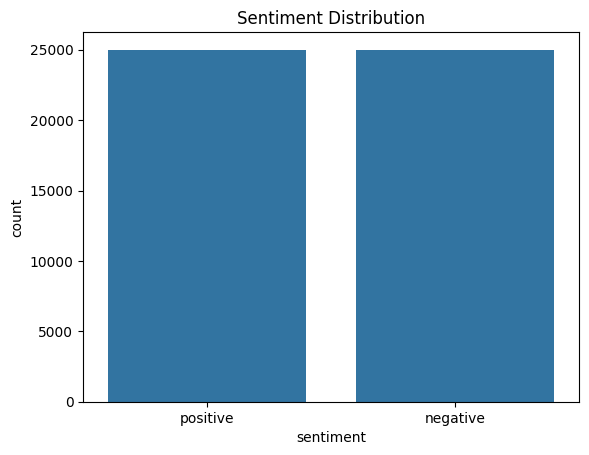

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

**3.2 Review Length Analysis**

In [ ]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

df.groupby('sentiment')['review_length'].mean()

,review_length
sentiment,
negative,229.46456
positive,232.84932


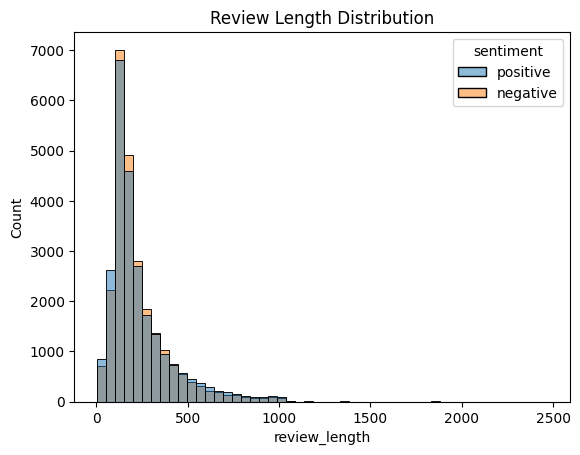

In [ ]:
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50)
plt.title("Review Length Distribution")
plt.show()

**3.3 Most Frequent Words**

In [ ]:
all_words = " ".join(df['review']).lower().split()
common_words = Counter(all_words).most_common(20)
common_words

[('the', 638861),
 ('a', 316615),
 ('and', 313637),
 ('of', 286661),
 ('to', 264573),
 ('is', 204876),
 ('in', 179807),
 ('i', 141587),
 ('this', 138483),
 ('that', 130140),
 ('it', 129614),
 ('/><br', 100974),
 ('was', 93258),
 ('as', 88242),
 ('with', 84590),
 ('for', 84510),
 ('but', 77864),
 ('on', 62890),
 ('movie', 61492),
 ('are', 57009)]

**4. Text Preprocessing**

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)       # remove HTML
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review,sentiment,review_length,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,307,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,162,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,166,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,138,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter mattei love time money visually stunnin...


**5. Tokenization & Padding**

In [ ]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_review'])

X = tokenizer.texts_to_sequences(df['cleaned_review'])
X = pad_sequences(X, maxlen=max_len)

**6. Encode Labels**

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

**7. Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**8. Build LSTM Model**

In [ ]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**9. Train Model**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 159s 313ms/step - accuracy: 0.7601 - loss: 0.4745 - val_accuracy: 0.8644 - val_loss: 0.3246
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 328ms/step - accuracy: 0.9208 - loss: 0.2178 - val_accuracy: 0.8845 - val_loss: 0.3064
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 193s 310ms/step - accuracy: 0.9471 - loss: 0.1497 - val_accuracy: 0.8733 - val_loss: 0.3662
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 336ms/step - accuracy: 0.9620 - loss: 0.1117 - val_accuracy: 0.8649 - val_loss: 0.4030
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 190s 312ms/step - accuracy: 0.9723 - loss: 0.0833 - val_accuracy: 0.8456 - val_loss: 0.4384


**10. Training Curves**

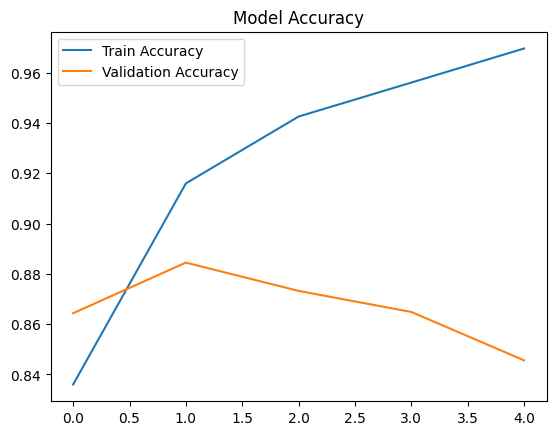

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

**11. Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8443 - loss: 0.4255
Test Accuracy: 0.8468000292778015


**11.1 Classification Report**

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      4961
           1       0.87      0.82      0.84      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



**11.2 Confusion Matrix**

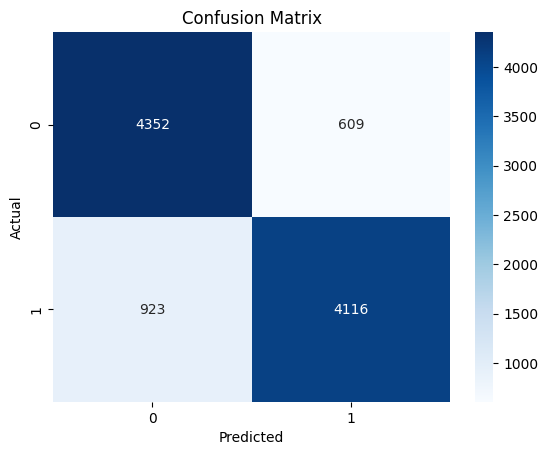

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**12. Simple Prediction Function**

In [ ]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prediction = model.predict(padded)

    return "Positive" if prediction > 0.5 else "Negative"

In [ ]:
predict_sentiment("This movie was absolutely TERRIBLE!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


'Negative'

**13. Model Saving**

In [ ]:
model.save("sentiment_lstm_model.keras")

In [12]:
!pip install mlflow


Defaulting to user installation because normal site-packages is not writeable


In [14]:
import mlflow
import mlflow.keras

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\typing_extensions.py)

In [ ]:
mlflow.set_experiment("IMDB_LSTM_Sentiment")

with mlflow.start_run():
    mlflow.log_param("max_words", max_words)
    mlflow.log_param("max_len", max_len)
    mlflow.log_param("epochs", 5)
    mlflow.log_metric("test_accuracy", accuracy)
    mlflow.keras.log_model(model, "lstm_model")

2026/02/25 21:42:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/25 21:42:13 INFO mlflow.store.db.utils: Updating database tables
2026/02/25 21:42:16 INFO mlflow.tracking.fluent: Experiment with name 'IMDB_LSTM_Sentiment' does not exist. Creating a new experiment.
2026/02/25 21:42:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 21:42:16 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


In [ ]:
!pip install fastapi uvicorn nest_asyncio pyngrok

In [ ]:
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
model.save("sentiment_lstm_model.h5")

In [ ]:
# Load trained model
model = tf.keras.models.load_model("sentiment_lstm_model.h5")

# IMPORTANT: Reload tokenizer from pickle if saved
import pickle

with open("tokenizer.pkl", "rb") as handle:
    tokenizer = pickle.load(handle)

max_len = 200

In [ ]:
with open("tokenizer.pkl", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
app = FastAPI(title="LSTM Sentiment Analysis API")

In [ ]:
class ReviewRequest(BaseModel):
    review: str

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

In [ ]:
@app.post("/predict")
def predict_sentiment(data: ReviewRequest):
    cleaned = clean_text(data.review)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)

    prediction = model.predict(padded)[0][0]

    sentiment = "Positive" if prediction > 0.5 else "Negative"

    return {
        "review": data.review,
        "sentiment": sentiment,
        "confidence": float(prediction)
    }

In [ ]:
!pip install "uvicorn[standard]" --upgrade

In [ ]:
# (Optional) Start FastAPI server externally
# It's recommended to run using a terminal command:
#   uvicorn api.app:app --host 127.0.0.1 --port 8000
# Trying to run the server inline in notebook can cause errors
# such as ``SyntaxError: 'await' outside function``.
# This cell is left here for documentation only.

INFO:     Started server process [917]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [917]


In [ ]:
# MLflow logging example
import mlflow
import mlflow.tensorflow

# assuming `model`, `X`, `y` are already defined in this notebook from training steps
with mlflow.start_run():
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 64)
    # note: training again on full dataset for demonstration
    model.fit(X, y, epochs=5, batch_size=64, validation_split=0.2)
    loss, accuracy = model.evaluate(X, y)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.tensorflow.log_model(model, "sentiment_lstm_model")

print("Logged model and metrics to MLflow.")

# To run the MLflow UI (execute in a separate terminal):
# 1. activate the same Python environment
# 2. run `mlflow ui --port 5000` or `python -m mlflow ui`
# 3. open http://localhost:5000 in your browser
# Running the UI inside the notebook can cause port conflicts or silent failures, 
# so it is better launched externally.

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\typing_extensions.py)